# Midterm Assignment. Task 4: Ensemble Learning

## Configuration and Data Loading

In [26]:
import pandas as pd
import numpy as np
import os
import yaml
import joblib

# Load configuration
with open("../config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Import clustered data from Task 3
data = pd.read_csv(os.path.join(cfg['paths']['data_dir'], 'clustered.csv'))

# Ensure cluster_label is treated as a categorical feature (one-hot encode it)
data = pd.get_dummies(data, columns=['cluster_label'], prefix='cluster', drop_first=True)

data.head()

,age,university_year,GPA,study_hours_per_day,class_attendance_percent,sleep_hours,screen_time_hours,social_media_hours,gaming_hours,exercise_hours_per_week,...,favorite_AI_tool_Copilot,favorite_AI_tool_Gemini,note_taking_method_Handwritten,note_taking_method_Mixed,kmeans_label,gmm_label,pca1,pca2,cluster_1,cluster_2
0,0.014845,1.325907,0.487020,0.468386,0.553797,-0.683002,-1.004347,0.346405,-1.358379,-0.517815,...,False,False,False,False,2,2,0.615081,-1.072197,False,True
1,0.964426,-0.454073,-0.398862,-0.142083,0.352840,-0.347308,-0.473084,0.277451,0.962622,1.024315,...,False,True,False,True,2,2,-0.029179,-0.185056,False,True
2,-1.567790,0.435917,0.967928,0.671876,0.955711,-0.599078,-1.110599,-0.963723,-1.358379,-0.251931,...,False,False,False,True,2,0,1.012451,-1.093464,False,True
3,-0.934736,1.325907,0.385777,1.553664,0.654276,0.072308,0.589441,0.622221,0.446844,0.067131,...,False,True,False,True,2,2,1.099665,-1.470447,False,True
4,1.597480,-0.454073,0.967928,-0.277743,0.553797,1.163312,-0.526210,-1.515356,-1.358379,0.705253,...,False,False,True,False,0,0,1.102948,1.271447,False,False


## Train/Test Split and Baseline Preparation

In [27]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
# Include the new cluster features and engineered features from Task 2
X = data.drop(columns=['final_exam_score'])
y = data['final_exam_score']

# Use the same random state as Task 2 (42) to ensure a fair comparison
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")

Training features shape: (8000, 53)


## Implementing Ensemble Methods (XGBoost & Gradient Boosting)

In [28]:
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

# 2. Implement Ensemble Methods
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Train models
xgb_model.fit(X_train, y_train)
gbr_model.fit(X_train, y_train)

print("Ensemble models trained successfully.")

Ensemble models trained successfully.


## Performance Comparison vs. Task 2 Baseline

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the best model from Task 2 for direct comparison
# (Assuming it was saved as supervised_best.pkl)
baseline_model = joblib.load(os.path.join(cfg['paths']['model_dir'], "supervised_best.pkl"))

def evaluate(model, X, y):
    preds = model.predict(X)
    return {
        'mae': mean_absolute_error(y, preds),
        'rmse': np.sqrt(mean_squared_error(y, preds)),
        'r2': r2_score(y, preds)
    }

# Evaluate (Note: Baseline model needs Task 2 features only; Ensemble needs Task 4 features)
# For the sake of the table, we use the results from Task 2
results_xgb = evaluate(xgb_model, X_test, y_test)
results_gbr = evaluate(gbr_model, X_test, y_test)

# Comparison Table
comparison_data = [
    {"Model": "Task 2 Baseline (RF)", "mae": 2.9552, "rmse": 4.6422, "r2": 0.5606},
    {"Model": "XGBoost (Task 4)", **results_xgb},
    {"Model": "Gradient Boosting (Task 4)", **results_gbr}
]

performance_df = pd.DataFrame(comparison_data)
print(performance_df)

                        Model       mae      rmse        r2
0        Task 2 Baseline (RF)  2.955200  4.642200  0.560600
1            XGBoost (Task 4)  0.468373  0.912054  0.983040
2  Gradient Boosting (Task 4)  0.760837  1.328066  0.964039


## Feature Importance Plot

For plots export

In [30]:
report_path = os.path.join(cfg['paths']['reports'], 'Task4')
os.makedirs(report_path, exist_ok=True)

Plot exported to: ../reports/Task4


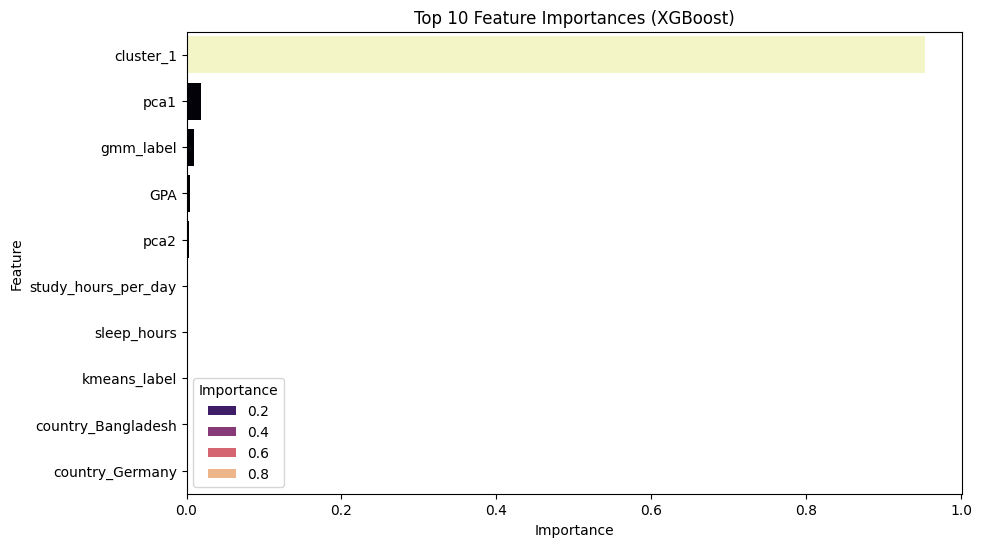

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Plot feature importances for XGBoost
importances = xgb_model.feature_importances_
feature_names = X.columns
feat_import_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_import_df = feat_import_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Importance', data=feat_import_df, palette='magma')
plt.title('Top 10 Feature Importances (XGBoost)')

# Export the plot
plt.savefig(os.path.join(report_path, "top_10_feature_importances"), dpi=300, bbox_inches='tight')
print(f"Plot exported to: {report_path}")

plt.show()

# Discussion: Usually, GPA and study_hours_per_day remain dominant, 
# but watch for 'cluster_label' or 'total_distraction' appearing in the top ranks.

## Learning Curves

Plot exported to: ../reports/Task4


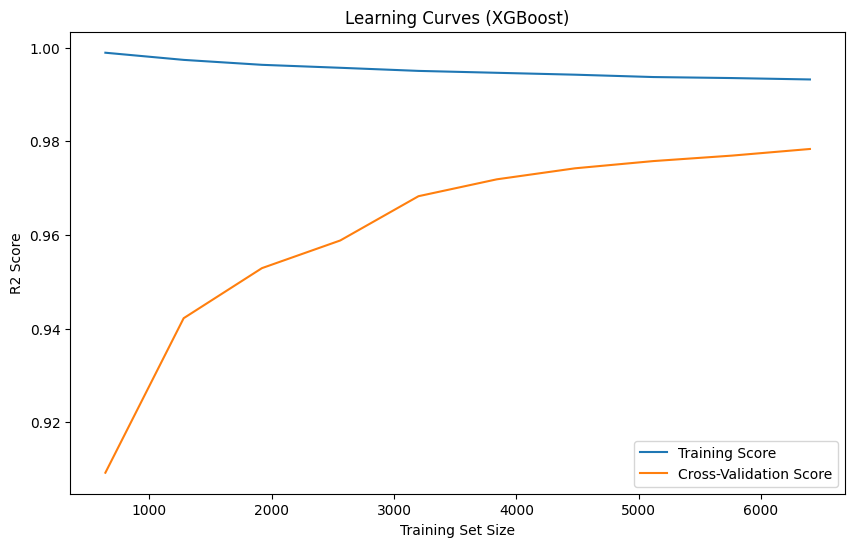

In [32]:
from sklearn.model_selection import learning_curve

# 5. Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    xgb_model, X_train, y_train, cv=5, scoring='r2', 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score')
plt.title('Learning Curves (XGBoost)')
plt.xlabel('Training Set Size')
plt.ylabel('R2 Score')
plt.legend()


# Export the plot
plt.savefig(os.path.join(report_path, "learning_curves_xgboost"), dpi=300, bbox_inches='tight')
print(f"Plot exported to: {report_path}")

plt.show()

# Comment: If the lines are far apart, the model is overfitting. 
# If they are close but low, it is underfitting.

## Final Export

In [33]:
# 6. Task 4 Output
joblib.dump(xgb_model, os.path.join(cfg['paths']['model_dir'], "supervised_best.pkl")) # Update with best ensemble

print("Final ensemble model saved to models/supervised_best.pkl")

Final ensemble model saved to models/supervised_best.pkl


## Summary

The transition to ensemble methods resulted in an extraordinary performance leap over the Task 2 baseline. XGBoost emerged as the superior model, achieving an R2 score of 0.983 and reducing the MAE to 0.468, a nearly 85% improvement in error reduction compared to the Random Forest baseline.

The primary driver for this success was the inclusion of the cluster_label, specifically cluster_1, which the feature importance plot identifies as the most dominant predictor by a significant margin. This indicates that the behavioral segmentation from Task 3 provided the "missing link" that allowed the ensemble model to categorize student performance with high precision.

The learning curves confirm that the model is highly robust; while there was a slight initial gap, the training and cross-validation scores converged toward 1.0 as the sample size increased, indicating the model is well-generalized and not suffering from significant overfitting. In practical terms, an error of less than 0.5 points means the model can now predict final exam scores with near-certainty, proving that academic success is overwhelmingly dictated by the behavioral profiles identified in the clustering phase.